In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# 1. Definizione dei dati estratti dalla tabella italiana
metrics_names = ['Cohesion Score', 'Normalized Entropy', 'Gini Coefficient', 'Coefficient Of Variation']
splits = ['train', 'dev', 'test']
versions = ['Base', 'Random', 'Optimized']

# Struttura: {Nome Metrica: [[Train Base, Train Rand, Train Opt], [Dev Base, Dev Rand, Dev Opt], [Test Base, Test Rand, Test Opt]]}
data = {
    'Cohesion Score': [
        [0.0426, 0.0436, 0.0367], 
        [0.0470, 0.0449, 0.0555], 
        [0.1490, 0.1099, 0.1154]
    ],
    'Normalized Entropy': [
        [0.6777, 0.6247, 0.7399], 
        [0.8476, 0.7953, 0.8014], 
        [0.4982, 0.5495, 0.6152]
    ],
    'Gini Coefficient': [
        [0.8486, 0.8850, 0.8070], 
        [0.5722, 0.6554, 0.6795], 
        [0.8699, 0.8626, 0.8468]
    ],
    'Coefficient Of Variation': [
        [2.8918, 3.3950, 2.6310], 
        [1.3496, 1.6135, 1.7119], 
        [3.0404, 2.6447, 2.7597]
    ]
}

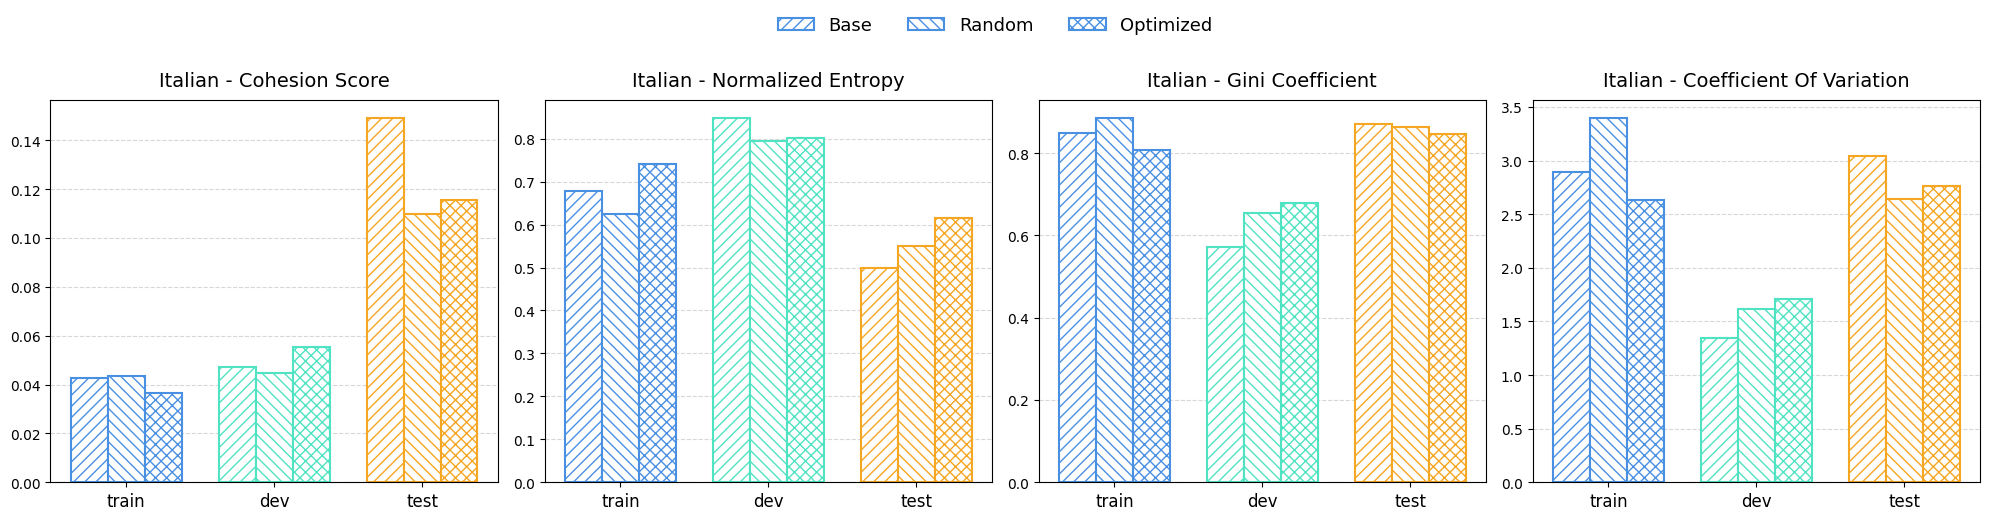

In [6]:
# 2. Impostazioni grafiche
colors = ['#4A90E2', '#50E3C2', '#F5A623'] # Blu (Train), Verde (Dev), Arancio (Test)
hatches = ['///', '\\\\\\', 'xxx']  # Pattern: Base, Random, Optimized

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
bar_width = 0.25
x_indexes = np.arange(len(splits))

# Variabili per conservare i campioni per la legenda globale
legend_handles = []
legend_labels = []

# 3. Generazione dei subplots
for i, metric in enumerate(metrics_names):
    ax = axes[i]
    metric_data = data[metric]
    
    for j, version in enumerate(versions):
        values = [metric_data[s_idx][j] for s_idx in range(len(splits))]
        
        for s_idx, val in enumerate(values):
            # Disegna la barra
            bar = ax.bar(x_indexes[s_idx] + j * bar_width, val, bar_width, 
                   facecolor='white',
                   edgecolor=colors[s_idx],
                   hatch=hatches[j],
                   linewidth=1.5)
            
            # Estrae gli elementi grafici solo dal primo grafico e dal primo split 
            # per costruire la legenda generale (associando i 3 tratteggi alle versioni)
            if i == 0 and s_idx == 0:
                legend_handles.append(bar[0])
                legend_labels.append(version)

    # Impostazioni di formattazione del singolo grafico
    ax.set_title(f'Italian - {metric}', fontsize=14, pad=10)
    ax.set_xticks(x_indexes + bar_width)
    ax.set_xticklabels(splits, fontsize=12)
    
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

# 4. Creazione della legenda globale (orizzontale in alto al centro)
fig.legend(legend_handles, legend_labels, loc='upper center', 
           ncol=3, fontsize=13, bbox_to_anchor=(0.5, 1.05), frameon=False)

# Aggiusta il layout per evitare sovrapposizioni e fare spazio alla legenda in alto
plt.tight_layout()
fig.subplots_adjust(top=0.85)

# Salvataggio
plt.savefig('italian_dynamicner_metrics.png', dpi=300, bbox_inches='tight')
plt.show()